<a href="https://colab.research.google.com/github/reneta-dimitrova96/Deep-Learning-Course-Project-2026/blob/main/02_TFIDF_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TF-IDF + Logistic Regression

## Notebook Objective

In this notebook, TF-IDF and Logistic Regression are used to build a baseline model for the paraphrase detection task.

The model will be trained and evaluated so its results can later be compared with the deep learning models.

The project uses the **PAWS-Wiki Labeled (Final)** dataset. The PAWS-Wiki dataset was released by Google Research and is used in this project for educational purposes. Google LLC (Google) is acknowledged as the data source.

### Sources

- [PAWS-Wiki Dataset on Hugging Face](https://huggingface.co/datasets/google-research-datasets/paws)
- [Official PAWS Repository by Google Research](https://github.com/google-research-datasets/paws)

## 1. Setup and Imports

In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## 2. Loading and Preparing the Dataset

The PAWS-Wiki `labeled_final` configuration is loaded from the Hugging Face Hub. The same cleaning steps from the EDA notebook will be applied before training the model.

In [ ]:
dataset = load_dataset(
    "google-research-datasets/paws",
    "labeled_final"
)

README.md:   0%|          | 0.00/9.79k [00:00<?, ?B/s]

labeled_final/train-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 8.43MB            

labeled_final/train-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

labeled_final/test-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 1.24MB            

labeled_final/test-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

labeled_final/validation-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B / 1.23MB            

labeled_final/validation-00000-of-00001.(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/49401 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 49401
    })
    test: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 8000
    })
})

### Converting the Dataset to DataFrames

The three dataset splits are converted to Pandas DataFrames to make the preparation steps easier.

In [ ]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

In [ ]:
print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (49401, 4)
Validation: (8000, 4)
Test: (8000, 4)


### Data Cleaning

During the EDA, some duplicate sentence pairs and pairs with conflicting labels were found. To apply the same cleaning steps to all dataset splits, a `clean_sentence_pairs()` function is created. It removes conflicting pairs and keeps only one occurrence of the remaining duplicates.

In [ ]:
def clean_sentence_pairs(df):
    pair_columns = ["sentence1", "sentence2"]

    # Find sentence pairs with conflicting labels
    conflicting_pairs = (
        df.groupby(pair_columns)["label"]
        .nunique()
        .reset_index()
    )

    conflicting_pairs = conflicting_pairs[
        conflicting_pairs["label"] > 1
    ]

    # Remove all rows belonging to conflicting pairs
    clean_df = df.merge(
        conflicting_pairs[pair_columns],
        on=pair_columns,
        how="left",
        indicator=True
    )

    clean_df = clean_df[
        clean_df["_merge"] == "left_only"
    ].drop(columns="_merge")

    # Keep only one occurrence of the remaining duplicate pairs
    clean_df = clean_df.drop_duplicates(
        subset=pair_columns
    ).reset_index(drop=True)

    return clean_df

In [ ]:
clean_train_df = clean_sentence_pairs(train_df)
clean_validation_df = clean_sentence_pairs(validation_df)
clean_test_df = clean_sentence_pairs(test_df)

In [ ]:
print("Train:", clean_train_df.shape)
print("Validation:", clean_validation_df.shape)
print("Test:", clean_test_df.shape)

Train: (49334, 4)
Validation: (7994, 4)
Test: (7977, 4)


After applying the same cleaning steps from the EDA, the datasets contain 49,334 training pairs, 7,994 validation pairs, and 7,977 test pairs.

## 3. Preparing the Input Data

For the baseline model, the two sentences in each pair are combined into a single text input. The labels are stored separately as the target values.

In [ ]:
clean_train_df["text_pair"] = (
    clean_train_df["sentence1"] + " [SEP] " + clean_train_df["sentence2"]
)

clean_validation_df["text_pair"] = (
    clean_validation_df["sentence1"] + " [SEP] " + clean_validation_df["sentence2"]
)

clean_test_df["text_pair"] = (
    clean_test_df["sentence1"] + " [SEP] " + clean_test_df["sentence2"]
)

In [ ]:
X_train = clean_train_df["text_pair"]
y_train = clean_train_df["label"]

X_validation = clean_validation_df["text_pair"]
y_validation = clean_validation_df["label"]

X_test = clean_test_df["text_pair"]
y_test = clean_test_df["label"]

In [ ]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (49334,) (49334,)
Validation: (7994,) (7994,)
Test: (7977,) (7977,)


## 4. TF-IDF Vectorization

Before training the model, the text pairs need to be converted into numerical features. TF-IDF is used for this step.

The vectorizer is fitted only on the training data, and the same vocabulary is then used to transform the validation and test sets.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_validation_tfidf = tfidf.transform(X_validation)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print("Train TF-IDF:", X_train_tfidf.shape)
print("Validation TF-IDF:", X_validation_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)

Train TF-IDF: (49334, 30000)
Validation TF-IDF: (7994, 30000)
Test TF-IDF: (7977, 30000)


## 5. Logistic Regression Model

A Logistic Regression model is used as the baseline classifier. The model is trained on the TF-IDF features from the training set and first evaluated on the validation set.

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_validation_pred = model.predict(X_validation_tfidf)

In [ ]:
validation_accuracy = accuracy_score(
    y_validation,
    y_validation_pred
)

validation_precision = precision_score(
    y_validation,
    y_validation_pred
)

validation_recall = recall_score(
    y_validation,
    y_validation_pred
)

validation_f1 = f1_score(
    y_validation,
    y_validation_pred
)

print(f"Accuracy:  {validation_accuracy:.4f}")
print(f"Precision: {validation_precision:.4f}")
print(f"Recall:    {validation_recall:.4f}")
print(f"F1-score:  {validation_f1:.4f}")

Accuracy:  0.5579
Precision: 0.5000
Recall:    0.2646
F1-score:  0.3460


In [ ]:
pd.Series(y_validation_pred).value_counts()

,count
0,6124
1,1870


In [ ]:
y_validation.value_counts()

,count
label,
0,4460
1,3534


### Validation Results

The first validation results show that the baseline model has difficulty identifying paraphrases. The accuracy is **55.79%**, while the recall for paraphrases is only **26.46%**, which means that many paraphrase pairs are predicted as non-paraphrases.

This suggests that the current TF-IDF representation has limited ability to separate the two classes.

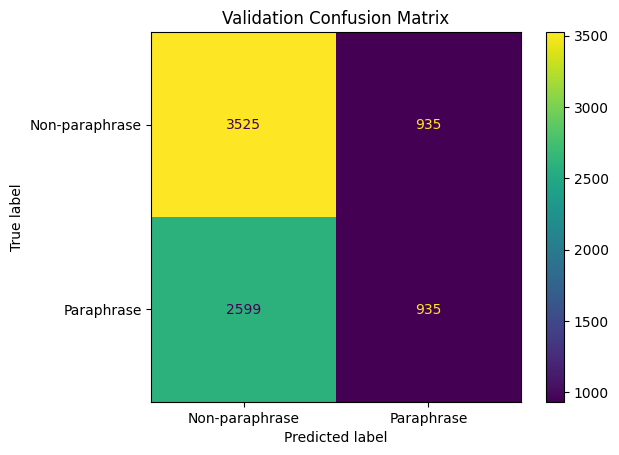

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    y_validation_pred,
    display_labels=["Non-paraphrase", "Paraphrase"]
)

plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_validation,
        y_validation_pred,
        target_names=["Non-paraphrase", "Paraphrase"]
    )
)

                precision    recall  f1-score   support

Non-paraphrase       0.58      0.79      0.67      4460
    Paraphrase       0.50      0.26      0.35      3534

      accuracy                           0.56      7994
     macro avg       0.54      0.53      0.51      7994
  weighted avg       0.54      0.56      0.52      7994



### Validation Results Summary

The confusion matrix shows that the model predicts non-paraphrases much more successfully than paraphrases. A large number of actual paraphrase pairs are classified as non-paraphrases, which explains the low recall for the paraphrase class.

Overall, the baseline model has difficulty separating the two classes using the current TF-IDF representation.

## 6. Balanced Logistic Regression

The first model predicts non-paraphrases much more often than paraphrases. A second Logistic Regression model is trained with balanced class weights to check whether this improves the results for the paraphrase class.

In [ ]:
balanced_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

In [ ]:
balanced_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_validation_pred_balanced = balanced_model.predict(
    X_validation_tfidf
)

In [ ]:
balanced_accuracy = accuracy_score(
    y_validation,
    y_validation_pred_balanced
)

balanced_precision = precision_score(
    y_validation,
    y_validation_pred_balanced
)

balanced_recall = recall_score(
    y_validation,
    y_validation_pred_balanced
)

balanced_f1 = f1_score(
    y_validation,
    y_validation_pred_balanced
)

print(f"Accuracy:  {balanced_accuracy:.4f}")
print(f"Precision: {balanced_precision:.4f}")
print(f"Recall:    {balanced_recall:.4f}")
print(f"F1-score:  {balanced_f1:.4f}")

Accuracy:  0.5353
Precision: 0.4771
Recall:    0.5340
F1-score:  0.5039


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        validation_accuracy,
        balanced_accuracy
    ],
    "Precision": [
        validation_precision,
        balanced_precision
    ],
    "Recall": [
        validation_recall,
        balanced_recall
    ],
    "F1-score": [
        validation_f1,
        balanced_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.557918,0.500000,0.264573,0.346040
1,Balanced Logistic Regression,0.535276,0.477118,0.533956,0.503939


The balanced model has slightly lower accuracy and precision, but it improves recall and F1-score considerably. It identifies more paraphrase examples instead of predicting the non-paraphrase class most of the time.

Because the performance between the two classes is more balanced, this version will be used as the final Logistic Regression baseline.

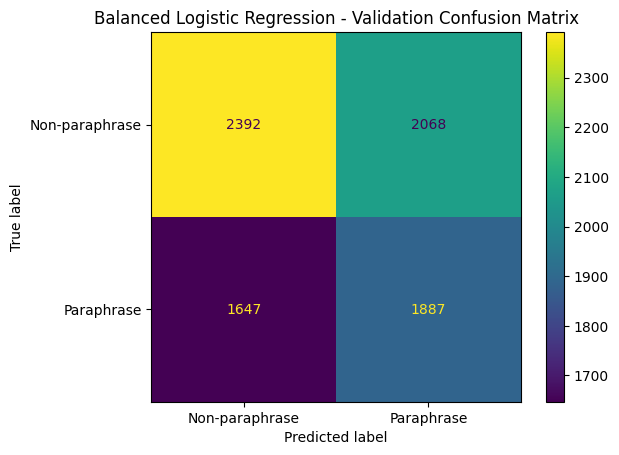

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    y_validation_pred_balanced,
    display_labels=["Non-paraphrase", "Paraphrase"]
)

plt.title("Balanced Logistic Regression - Validation Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_validation,
        y_validation_pred_balanced,
        target_names=["Non-paraphrase", "Paraphrase"]
    )
)

                precision    recall  f1-score   support

Non-paraphrase       0.59      0.54      0.56      4460
    Paraphrase       0.48      0.53      0.50      3534

      accuracy                           0.54      7994
     macro avg       0.53      0.54      0.53      7994
  weighted avg       0.54      0.54      0.54      7994



The confusion matrix and classification report show that the balanced model performs more evenly across both classes. The results for paraphrases improve, while the performance for non-paraphrases becomes lower but more balanced overall.

This makes the model more suitable as a baseline for comparison with the later deep learning models.

## 7. Final Evaluation on the Test Set

The selected balanced Logistic Regression model is evaluated on the test set to measure its final performance on unseen data.

In [ ]:
y_test_pred = balanced_model.predict(X_test_tfidf)

In [ ]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")

Accuracy:  0.5295
Precision: 0.4718
Recall:    0.5521
F1-score:  0.5088


The test results are similar to the validation results, which shows that the model behaves consistently on unseen data. The recall is slightly higher on the test set, while the other metrics remain close to the validation results.

The overall performance is still limited, so this model will be used as the baseline for comparison with the deep learning models.

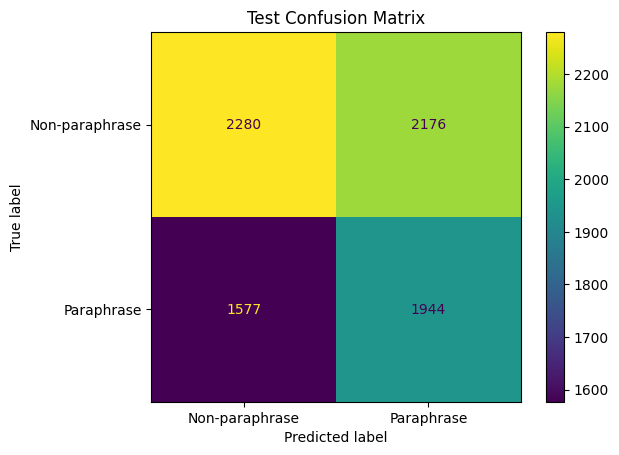

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Non-paraphrase", "Paraphrase"]
)

plt.title("Test Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Non-paraphrase", "Paraphrase"]
    )
)

                precision    recall  f1-score   support

Non-paraphrase       0.59      0.51      0.55      4456
    Paraphrase       0.47      0.55      0.51      3521

      accuracy                           0.53      7977
     macro avg       0.53      0.53      0.53      7977
  weighted avg       0.54      0.53      0.53      7977



The test results show a fairly similar performance for both classes. The model identifies paraphrases slightly better in terms of recall, but the overall scores remain moderate. This confirms that the TF-IDF + Logistic Regression approach provides a useful baseline, but it has limitations for this task.

## 8. Final Summary

The main findings from this notebook are:

- TF-IDF was used to convert the text pairs into numerical features.
- The first Logistic Regression model performed better on non-paraphrases and had low recall for paraphrases.
- Using balanced class weights improved the recall and F1-score for the paraphrase class and produced more similar results for both classes.
- The validation and test results were close to each other, which shows that the model behaves consistently on unseen data.
- The final test results show that the overall performance is still limited, so this model will be used as a baseline for the next experiments.

The baseline results will be used as a reference for comparison with the deep learning models in the next stages of the project.